In [ ]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from stimulus_generator import (
    generate_bar_batch,
    generate_grating_batch,
    generate_static_batch,
    generate_stimulus_batch,
    SyntheticMotionDataset,
)

In [ ]:
batch_size = 32
num_batches_per_epoch = 2000 // batch_size
train_dataset = SyntheticMotionDataset(num_batches=num_batches_per_epoch, batch_size=batch_size, T=24, width=16)
dataloader = DataLoader(train_dataset, batch_size=None) # batches are pre-formed by the dataset

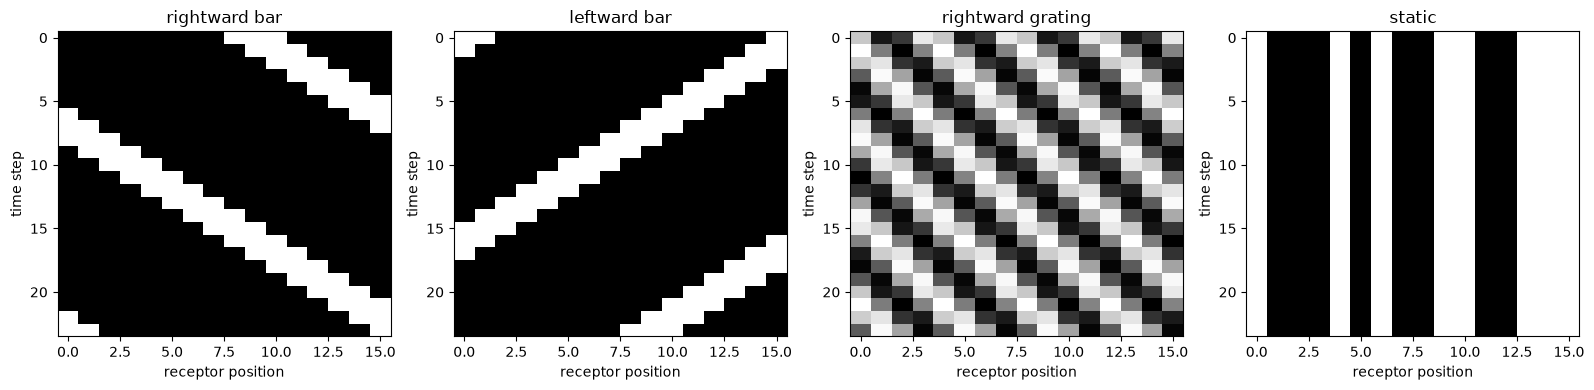

In [5]:
examples = {
    "rightward bar": generate_bar_batch(1, 24, direction=1, speed=1.0)[0],
    "leftward bar": generate_bar_batch(1, 24, direction=-1, speed=1.0)[0],
    "rightward grating": generate_grating_batch(1, 24, direction=1)[0],
    "static": generate_static_batch(1, 24)[0],
}

fig, axes = plt.subplots(1, len(examples), figsize=(16, 4))
for ax, (title, stim) in zip(axes, examples.items()):
    ax.imshow(stim.numpy(), aspect="auto", cmap="gray")
    ax.set_title(title)
    ax.set_xlabel("receptor position")
    ax.set_ylabel("time step")
plt.tight_layout()
plt.show()